In [1]:
import numpy as np
from numpy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from scipy.signal.windows import blackman

In [2]:
data = np.load(r'/home/cameron/Desktop/research/rfsoc_analysis/data/big_buffer_500pairs.npy')

'''
Indices of bad ddfs for big_buffer_500pairs.npy (ddf > 0.1)
[  1   5  10  22  58  77 107 146 155 168 176 177 194 225 235 299 324 329
 330 333 380 429 443 498]
'''

'\nIndices of bad ddfs for big_buffer_500pairs.npy (ddf > 0.1)\n[  1   5  10  22  58  77 107 146 155 168 176 177 194 225 235 299 324 329\n 330 333 380 429 443 498]\n'

In [3]:
data.shape
SAMP_FREQ = 4e9 / 16

TIME_DOMAIN = np.arange(data.shape[-1]) / SAMP_FREQ

In [4]:
num_pairs = data.shape[0]
num_samp = data.shape[2]

iq_data = np.zeros((2, num_pairs, num_samp), dtype=np.complex128)
iq_data[0] = data[:,0,:] + 1j*data[:,1,:]
iq_data[1] = data[:,2,:] + 1j*data[:,3,:]

data = None

In [5]:
# fig, ax = plt.subplots()
# ax.plot(np.real(iq_data[0,0,:50]))
# plt.show()

In [11]:
iq_data_new2, iq_data_new = None, None

freq_domain = fftfreq(num_samp, 1/SAMP_FREQ)
iq_data_freq = fft(blackman(num_samp)*iq_data, axis=2)

carrier_indices = np.argmax(np.abs(iq_data_freq), axis=2)
carrier_freqs = freq_domain[carrier_indices]

slices = carrier_indices[:,:,np.newaxis] + np.arange(-3, 4)[np.newaxis,np.newaxis,:]
freq_neighborhoods = np.take_along_axis(np.repeat(np.repeat(freq_domain[np.newaxis,:], slices.shape[1], axis=0)[np.newaxis,:,:], slices.shape[0], axis=0), slices, axis=2) # gross repeating thing in first position just puts a copy of freq domain into every entry of a (2,500) array
iq_data_freq_neighborhoods = np.abs(np.take_along_axis(iq_data_freq, slices, axis=2))
slices = None
carrier_freqs_better = np.sum(freq_neighborhoods * iq_data_freq_neighborhoods/np.sum(iq_data_freq_neighborhoods, axis=2)[:,:,np.newaxis], axis=2)
iq_data_freq_neighborhoods = None
freq_neighborhoods = None
print(carrier_freqs_better.shape)
print(carrier_freqs_better)


# a = freq_domain[carrier_indices[0,0] - 3: carrier_indices[0,0] + 4]
# print(a)
# print(np.average(a))
# print(carrier_freqs[0,0])
# w = np.abs(iq_data_freq[0,0,carrier_indices[0,0] - 3: carrier_indices[0,0] + 4])
# print(w)
# w /= np.sum(w)
# print(w)
# print(np.sum(w*a))
# better_freq = np.sum(w*a)

row_inds = np.arange(2)[:,None]
col_inds = np.arange(num_pairs)
carrier_phases = np.abs(np.angle(iq_data_freq[row_inds, col_inds, carrier_indices]))
# print(carrier_phases)

iq_data_freq, row_inds, col_inds, carrier_indices = None, None, None, None

(2, 500)
[[12019875.39065225 12019882.85116343 12019883.04616498 12019883.19541463
  12019881.592085   12019878.52101381 12019878.48297074 12019877.59146503
  12019879.63876902 12019883.75232205 12019877.79961408 12019882.12788618
  12019878.84802309 12019881.54854308 12019877.60945472 12019881.93032743
  12019882.30202609 12019883.00728736 12019883.20711313 12019880.345859
  12019885.74268704 12019884.62359061 12019887.9216989  12019891.80765866
  12019889.03081769 12019886.62843904 12019890.34954734 12019889.50064144
  12019889.22360982 12019888.62131991 12019894.51004123 12019893.80085948
  12019892.12324153 12019897.43648092 12019895.38571401 12019897.06558964
  12019898.16635154 12019895.60560453 12019896.21466594 12019898.29271692
  12019900.04673722 12019900.58745634 12019900.60538664 12019901.14898618
  12019903.29976146 12019905.29270229 12019904.52105463 12019906.62609222
  12019908.21646299 12019908.39824678 12019912.22100599 12019910.15121462
  12019913.17663293 12019912.30

In [12]:
iq_data_new2, iq_data_new = None, None

# iq_data_new2 = iq_data * np.exp(-1j * (2*np.pi*carrier_freqs[:,:,np.newaxis]/SAMP_FREQ*np.arange(num_samp) - carrier_phases[:,:,np.newaxis]))

iq_data_new = iq_data * np.exp(-1j * (2*np.pi*carrier_freqs_better[:,:,np.newaxis]/SAMP_FREQ*np.arange(num_samp)  - carrier_phases[:,:,np.newaxis]))
# print(np.average(np.angle(iq_data_new), axis=2)[:,31])
iq_data_new *= np.exp(-1j*np.average(np.unwrap(np.angle(iq_data_new)), axis=2)[:,:,np.newaxis])
# iq_data_new3 = iq_data_new2 * np.exp()

carrier_phases, carrier_freqs, carrier_freqs_better = None, None, None

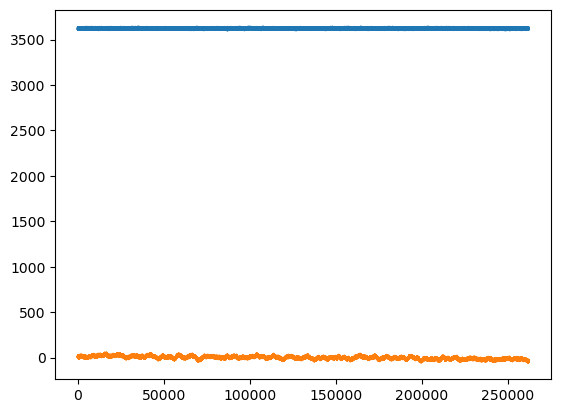

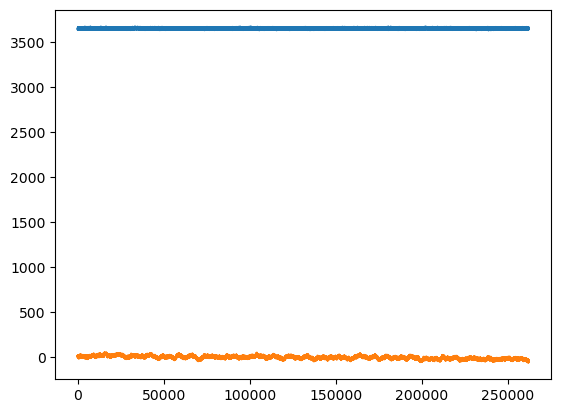

In [13]:
pair = 31

fig, ax = plt.subplots()
ax.plot(np.real(iq_data_new[0,pair,:50000000]))
ax.plot(np.imag(iq_data_new[0,pair,:50000000]))
# ax.plot(np.real(iq_data_new2[0,pair,:50000000]))
# ax.plot(np.imag(iq_data_new2[0,pair,:50000000]))
plt.show()

fig, ax = plt.subplots()
ax.plot(np.real(iq_data_new[1,pair,:50000000]))
ax.plot(np.imag(iq_data_new[1,pair,:50000000]))
# ax.plot(np.real(iq_data_new2[1,pair,:50000000]))
# ax.plot(np.imag(iq_data_new2[1,pair,:50000000]))
plt.show()

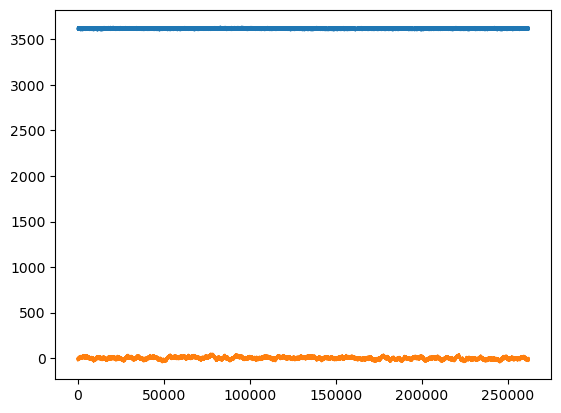

In [117]:
#iq_data_new *= np.average(np.angle(iq_data_new), axis=2)[:,:,np.newaxis]

fig, ax = plt.subplots()
ax.plot(np.real(iq_data_new[0,pair,:50000000]))
ax.plot(np.imag(iq_data_new[0,pair,:50000000]))
plt.show()

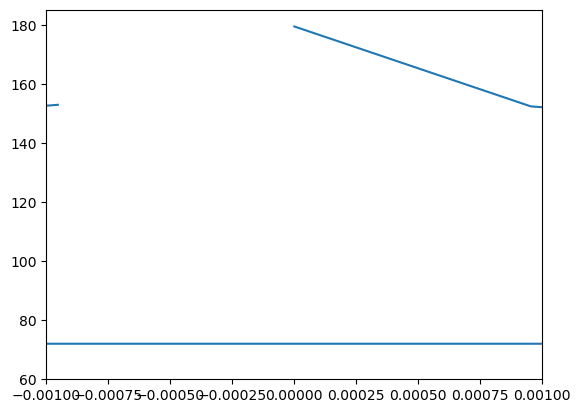

In [66]:
fig, ax = plt.subplots()
ax.plot(fftfreq(num_samp, 1/SAMP_FREQ)*1e-6, 20*np.log10(np.average(np.abs(fft(iq_data_new, axis=2)[0,:,:]), axis=0)))
ax.set_xlim(-1e-3, 1e-3)
plt.show()

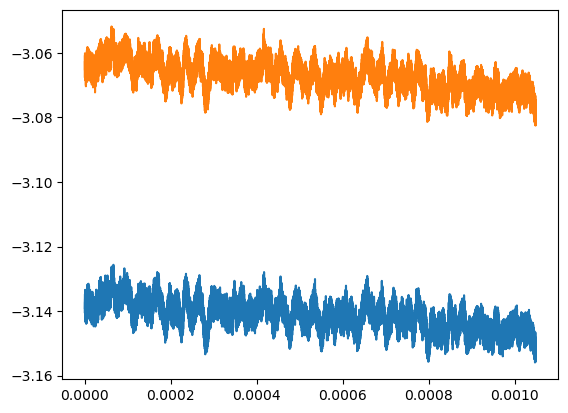

-0.7548963748926932


In [10]:
pair = 31

fig, ax = plt.subplots()
ax.plot(TIME_DOMAIN, np.unwrap(np.angle(iq_data_new[0,pair,:])))
ax.plot(TIME_DOMAIN, np.unwrap(np.angle(iq_data_new[1,pair,:])))
# ax.plot(TIME_DOMAIN, np.angle(iq_data_new2[1,pair,:]))
plt.show()

print((np.angle(iq_data_new[0,0,-1]) - np.angle(iq_data_new[0,0,0]))/TIME_DOMAIN[-1]/(2*np.pi))

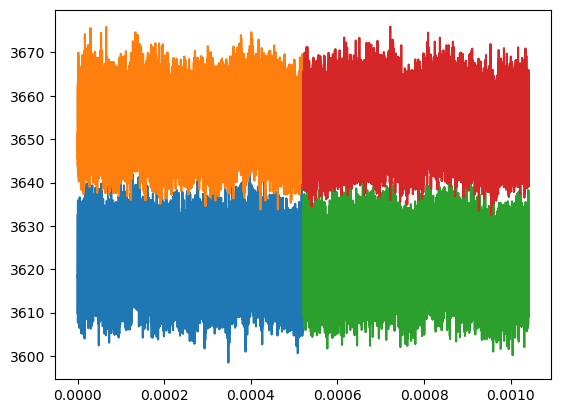

In [15]:
a = np.real(iq_data_new[:,31,:])
a.shape

FLIP_FREQ = 1.92e3
time_domain = np.arange(num_samp)/SAMP_FREQ
mask_l = (time_domain >= 0) & (time_domain < 1/FLIP_FREQ)
mask_r = (time_domain >= 1/FLIP_FREQ) & (time_domain < 2/FLIP_FREQ)



fig, ax = plt.subplots()
ax.plot(time_domain[mask_l], a[0,mask_l])
ax.plot(time_domain[mask_l], a[1,mask_l])
ax.plot(time_domain[mask_r], a[0,mask_r])
ax.plot(time_domain[mask_r], a[1,mask_r])
plt.show()

In [16]:
ch1_l = np.average(a[0, mask_l])
ch1_r = np.average(a[0, mask_r])
ch2_l = np.average(a[1, mask_l])
ch2_r = np.average(a[1, mask_r])

print((ch1_l - ch1_r)/(ch1_l + ch1_r))
print((ch2_l - ch2_r)/(ch2_l + ch2_r))

print(1/np.sqrt(2)*((ch2_l - ch2_r)/(ch2_l + ch2_r) - (ch1_l - ch1_r)/(ch1_l + ch1_r)))

l_data = np.average(np.real(iq_data_new)[:,:,mask_l], axis=2)
r_data = np.average(np.real(iq_data_new)[:,:,mask_r], axis=2)

rdfs = (r_data - l_data)/(r_data + l_data)
ddfs = 1/np.sqrt(2) * (rdfs[0] - rdfs[1])
print(ddfs[380])

5.0581600923400994e-05
5.084712064099408e-05
1.8775079284880649e-07
7.334154362593401e-06


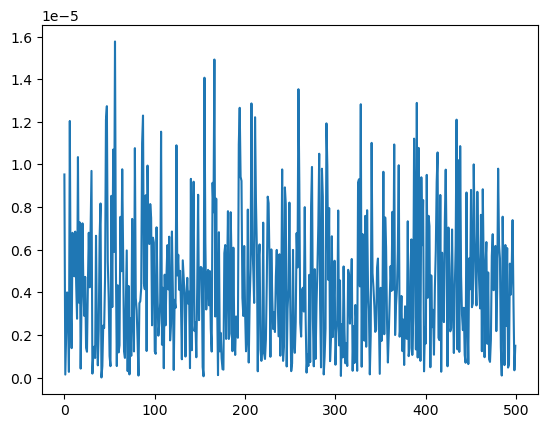

[]
[]


In [17]:
fig, ax = plt.subplots()
ax.plot(np.abs(ddfs))
plt.show()

indices = np.arange(ddfs.size)
mask = np.abs(ddfs) > 0.0001
bad_ddfs = ddfs[mask]
bad_indices = indices[mask]
print(bad_ddfs)
print(bad_indices)
